<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 3, Vanilla RNN y Vanishing Gradient**

Importamos las librerías necesarias

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import urllib.request
from scipy.io import wavfile

Fijamos las semillas para reproducibilidad

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

Descargamos y preparamos el audio

In [ ]:
URL = "https://raw.githubusercontent.com/pytorch/audio/main/test/torchaudio_unittest/assets/steam-train-whistle-daniel_simon.wav"
urllib.request.urlretrieve(URL, "tren.wav")
sr, w = wavfile.read("tren.wav")
audio = w.mean(axis=1).astype(np.float32) # convertimos a mono
audio = audio[::4]  # submuestreamos a 11,025 Hz
audio = audio / np.abs(audio).max()  # normalizamos a [-1, 1]

Tomamos una ventana de 160 muestras para ver la RNN por dentro

In [ ]:
L = 160
x = torch.tensor(audio[:L]).reshape(1, L, 1)  # forma (1 ventana, 160 pasos, 1 canal)

Definimos las dos matrices de pesos de la celda: W_x (entrada) y W_h (recurrente)

In [ ]:
d_h = 16  # tamaño del estado oculto
Wx = nn.Linear(1, d_h, bias=False) # qué aporta la observación nueva
Wh = nn.Linear(d_h, d_h)  # qué aporta la memoria (incluye el bias)

Inicializamos el estado oculto en ceros

In [ ]:
h = torch.zeros(1, d_h)

Recorremos la ventana paso a paso aplicando siempre los mismos pesos (parameter sharing)

In [ ]:
historia = []
for t in range(L):
    h = torch.tanh(Wx(x[:, t]) + Wh(h))  # la ecuación del slide: h_t = tanh(Wx·x_t + Wh·h_{t-1} + b)
    historia.append(h.detach().numpy()[0])  # guardamos el estado de este paso

Graficamos el unrolling: el estado evolucionando a lo largo de la ventana

Cada fila es una neurona.

Cada columna es un instante del audio.

Los colores indican la activación.

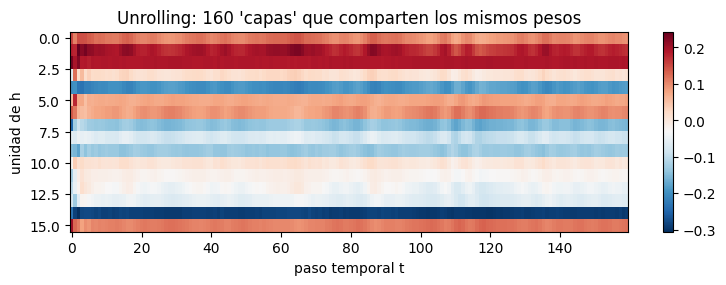

In [ ]:
plt.figure(figsize=(9, 2.6))
plt.imshow(np.array(historia).T, aspect="auto", cmap="RdBu_r")
plt.xlabel("paso temporal t")
plt.ylabel("unidad de h")
plt.title("Unrolling: 160 'capas' que comparten los mismos pesos")
plt.colorbar()
plt.show()

Ahora medimos el vanishing: cuánto gradiente le llega a cada posición de la ventana


Creamos un batch de ventanas aleatorias que exigen gradiente

In [ ]:
xg = torch.randn(128, L, 1, requires_grad=True)

Definimos una RNN vanilla de PyTorch y una cabeza lineal de salida

In [ ]:
rnn = nn.RNN(1, 32, batch_first=True)
cabeza = nn.Linear(32, 1)

Realizamos el forward: la RNN recorre las ventanas y la cabeza predice desde el último estado

In [ ]:
salida, _ = rnn(xg)
prediccion = cabeza(salida[:, -1])

Calculamos una pérdida y propagamos el gradiente hacia atrás en el tiempo (BPTT)

In [ ]:
perdida = (prediccion**2).mean()
perdida.backward()

Medimos la norma del gradiente que recibió cada posición de la ventana

¿Cuánto gradiente recibió cada instante de la secuencia?

In [ ]:
grad_por_posicion = xg.grad.norm(dim=(0, 2)).numpy()

Graficamos en escala log.


Si usáramos una escala lineal, todos los valores pequeños parecerían cero.


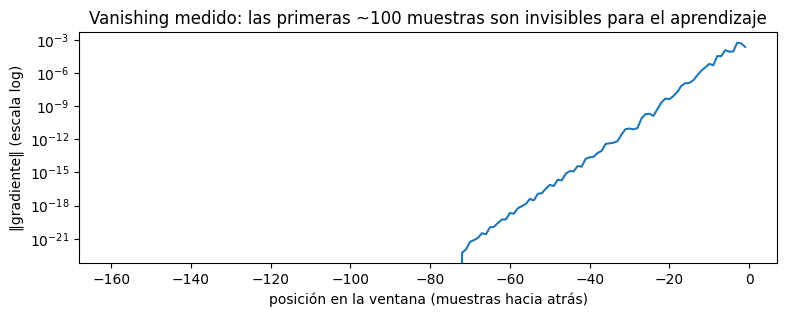

In [ ]:
plt.figure(figsize=(9, 3))
plt.semilogy(range(-L, 0), grad_por_posicion)
plt.xlabel("posición en la ventana (muestras hacia atrás)")
plt.ylabel("‖gradiente‖ (escala log)")
plt.title("Vanishing medido: las primeras ~100 muestras son invisibles para el aprendizaje")
plt.show()